# Forecasting of El Niño
___

## Dataset

In [12]:
%pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import numpy as np

ds_sst = xr.open_dataset("sst.mnmean.nc", engine="netcdf4")
sst = ds_sst['sst']

## Plotting El Nino

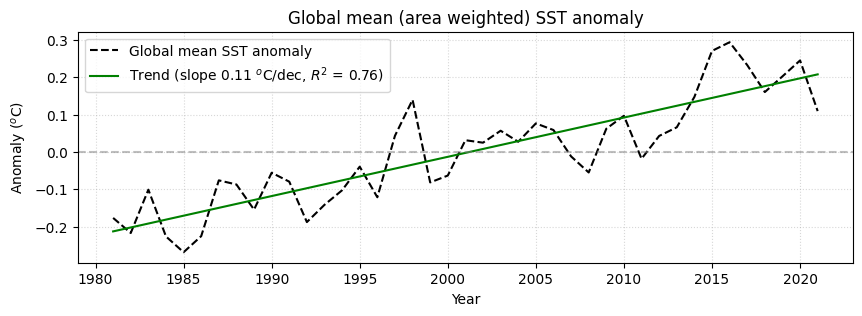

In [14]:
sst_mean = sst.mean('time')
sst_std = sst.std('time')

proj = ccrs.PlateCarree()

sst_month = sst.groupby('time.month').mean('time')
sst_month_dev = sst_month - sst_mean

sst_deseason = sst.groupby('time.month') - sst_month

# For global SST
weights = np.cos(np.deg2rad(sst_deseason['lat']))   
# because area of each pixel is proportional to the cosinus of the latitude
sst_des_w_mean = sst_deseason.weighted(weights).mean(dim = ['lat', 'lon'])
global_annual_mean = sst_des_w_mean.groupby('time.year').mean('time')

p = global_annual_mean.polyfit(dim='year', deg=1)

fit_line = xr.polyval(global_annual_mean['year'], p.polyfit_coefficients)

warming_rate_per_year = p.polyfit_coefficients.sel(degree=1).item()
warming_rate_per_decade = warming_rate_per_year * 10
r = xr.corr(global_annual_mean, fit_line, dim='year').item()
r2 = r**2

fig, ax = plt.subplots(figsize = (10,3))
global_annual_mean.plot(ax = ax, color = 'black', linestyle= '--', label = 'Global mean SST anomaly')

fit_line.plot(ax=ax, color='green', linestyle='-',
    label=f'Trend (slope {warming_rate_per_decade:.2f} $^o$C/dec, $R^2$ = {r2:.2f})')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Global mean (area weighted) SST anomaly")
ax.set_ylabel("Anomaly ($^o$C)")
ax.set_xlabel("Year")
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend()

plt.show()

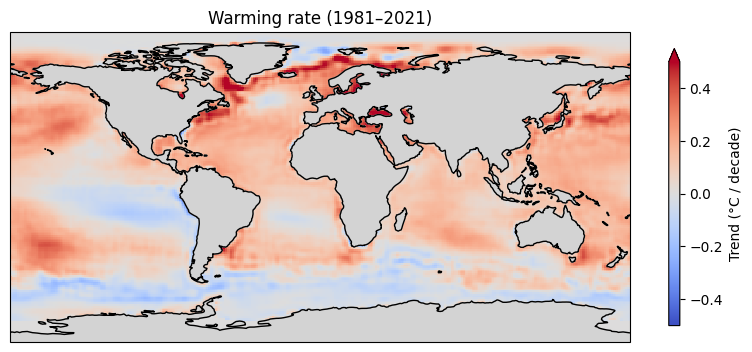

In [15]:
trend = sst_deseason.polyfit(dim="time", deg=1)
predicted_sst = xr.polyval(sst_deseason["time"], trend.polyfit_coefficients)


# Convert slope to °C/decade
ns_per_decade = 10 * 365 * 24 * 3600 * 1e9
slope_per_decade = trend.polyfit_coefficients.sel(degree=1) * ns_per_decade

# Plot
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": proj})

slope_per_decade.plot(ax=ax, transform=ccrs.PlateCarree(), center=0, vmin=-0.5, vmax=0.5, cmap="coolwarm", cbar_kwargs={"label": "Trend (°C / decade)", "shrink": 0.6, "aspect": 25})

ax.set_title("Warming rate (1981–2021)")
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray", zorder=1)

plt.show()

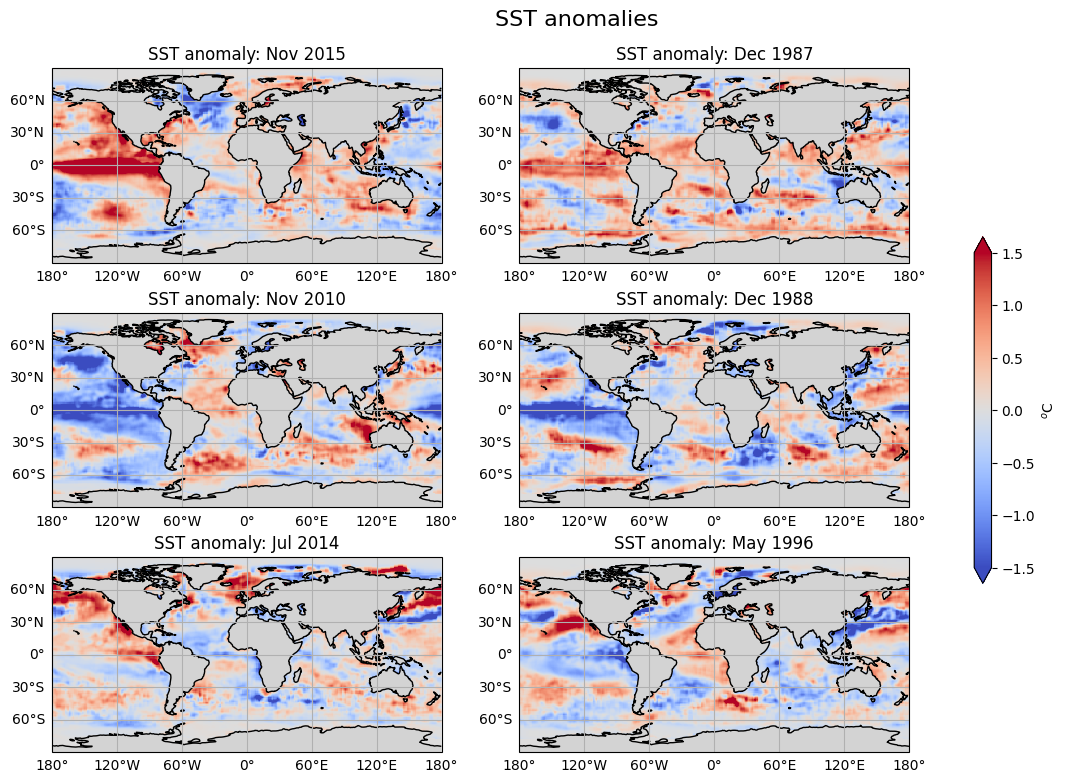

In [ ]:
sst_anom = sst_deseason - predicted_sst

del sst_deseason, predicted_sst

SELECTED_DATES = ['2015-11-01', '1987-12-01', '2010-11-01', '1988-12-01', '2014-07-01', '1996-05-01']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14,9), subplot_kw={'projection': proj})
axes = axes.flatten()

limit = 1.5 #threshold for very strong ENSO episodes

for i, date in enumerate(SELECTED_DATES):
    sst_date = sst_anom.sel(time=date)
    im = sst_date.plot(ax=axes[i], transform = proj, cmap='coolwarm', vmin=-limit, vmax=limit, add_colorbar=False)
    axes[i].coastlines()
    axes[i].add_feature(cfeature.LAND, zorder=1, facecolor='lightgray')
    axes[i].set_title(f"SST anomaly: {pd.to_datetime(date).strftime('%b %Y')}")
    gl = axes[i].gridlines(draw_labels = True)
    gl.top_labels = False
    gl.right_labels = False

cbar = fig.colorbar(im, ax=axes, orientation='vertical', extend = 'both', pad=0.06, shrink = 0.5)
cbar.set_label('$^o$C')

plt.suptitle("SST anomalies", fontsize = 16, y = 0.94)

plt.show()

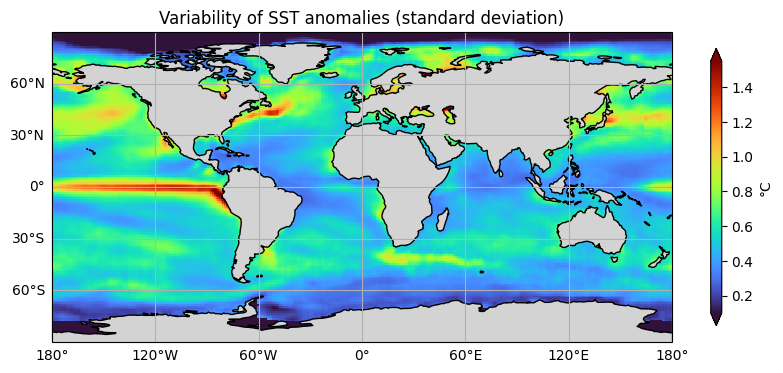

In [17]:
# We can see that the area with that shows the most variability is the Tropical Pacific

fig, ax = plt.subplots(figsize = (10,6),subplot_kw={'projection':proj})
sst_anom.std('time').plot(ax = ax,transform = proj, cmap = 'turbo', vmin = 0.1,vmax = 1.55, extend = 'both', cbar_kwargs={"label": "°C", "shrink": 0.6, "aspect": 25})
ax.coastlines()
ax.add_feature(cfeature.LAND, zorder = 1, facecolor = 'lightgray')
ax.set_title('Variability of SST anomalies (standard deviation)')
gl = ax.gridlines(draw_labels = True)
gl.top_labels = False
gl.right_labels = False
plt.show()

## Computing ONI Index for El Nino 3.4

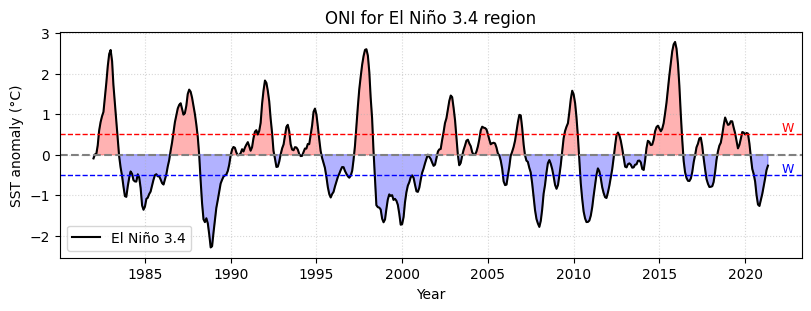

In [18]:
# Tropical Pacific subset
min_lon, max_lon = 120, 290
min_lat, max_lat = -20, 12.5
sst_tropical = sst_anom.sel(lat=slice(max_lat, min_lat), lon=slice(min_lon, max_lon))

# El Niño 3.4 box (min_lat, max_lat, min_lon, max_lon)
n_34 = (-5, 5, 190, 240)
min_lat, max_lat, min_lon, max_lon = n_34

# Compute ONI for Niño 3.4
sst_region = sst_tropical.sel(lat=slice(max_lat, min_lat), lon=slice(min_lon, max_lon))
weights_region = weights.sel(lat=slice(max_lat, min_lat))

sst_region_mean = sst_region.weighted(weights_region).mean(dim=["lat", "lon"])
oni_34 = sst_region_mean.rolling(time=3, center=True).mean().dropna("time")

# Plot
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")

oni_34.plot(ax=ax, color="black", label="El Niño 3.4")
ax.axhline(0, color="gray", ls="--")

thresholds = [
    (0.5,  "W",  "red", 1.0),
    (-0.5, "W",  "blue", 1.0)]

for val, label, color, lw in thresholds:
    ax.axhline(val, color=color, ls="--", lw=lw)
    ax.text(0.99, val, label, color=color, transform=ax.get_yaxis_transform(), va="bottom", ha="right", fontsize=9)

# Shading
ax.fill_between(oni_34.time, oni_34, 0, where=(oni_34 >= 0), color="red", alpha=0.3, interpolate=True)
ax.fill_between(oni_34.time, oni_34, 0, where=(oni_34 <= 0), color="blue", alpha=0.3, interpolate=True)

ax.set_title("ONI for El Niño 3.4 region")
ax.set_ylabel("SST anomaly (°C)")
ax.set_xlabel("Year")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()

plt.show()

In [19]:
url = "https://www.cpc.ncep.noaa.gov/data/indices/sstoi.indices"

col_names = ["Year", "Month", "N12_SST", "N12_ANOM", "N3_SST",  "N3_ANOM", "N4_SST",  "N4_ANOM", "N34_SST", "N34_ANOM"]
df_official = pd.read_csv(url, sep=r'\s+',skiprows=1, names=col_names, engine='python')
df_official['Date'] = pd.to_datetime(
    df_official['Year'].astype(str) + '-' + df_official['Month'].astype(str) + '-01')
df_official = df_official.set_index('Date')

official_oni = df_official[["N12_ANOM", "N3_ANOM", "N4_ANOM", "N34_ANOM"]].rolling(3, center=True).mean().dropna()

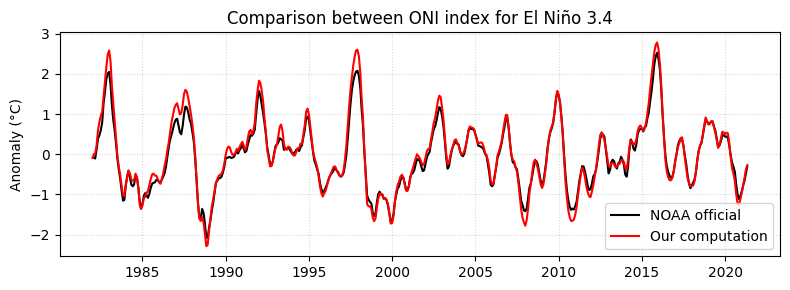

In [20]:
fig, ax = plt.subplots(figsize=(8, 3))

# Official NOAA series
obs = official_oni["N34_ANOM"]

t0 = pd.to_datetime(oni_34.time.min().values)
t1 = pd.to_datetime(oni_34.time.max().values)

obs = obs.loc[t0:t1]

ax.plot(obs.index, obs, color="black", label="NOAA official")

# Your computed ONI
ax.plot(oni_34.time, oni_34, color="red", label="Our computation")

ax.set_title("Comparison between ONI index for El Niño 3.4")
ax.set_ylabel("Anomaly (°C)")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

## EOF Analysis

In [21]:
# we have sst_tropical and weights. We need to adjust the values depending on the corresponding area weight
min_lon = 120
max_lon = 290
min_lat = -20
max_lat = 12.5
weights_tropical = np.sqrt(weights.sel(lat = slice(max_lat, min_lat)))

sst_trop_weighted = sst_tropical * weights_tropical
# We need to flatten to perform PCA
sst_flat = sst_trop_weighted.stack(z=("lat", "lon"))
X = sst_flat.values

from sklearn.decomposition import PCA
n_modes = 10
pca = PCA(n_components=n_modes)
pca.fit(X)

pcs = pca.transform(X)

eofs_unit = pca.components_
eigenvalues = pca.explained_variance_
explained_variance = pca.explained_variance_ratio_ * 100

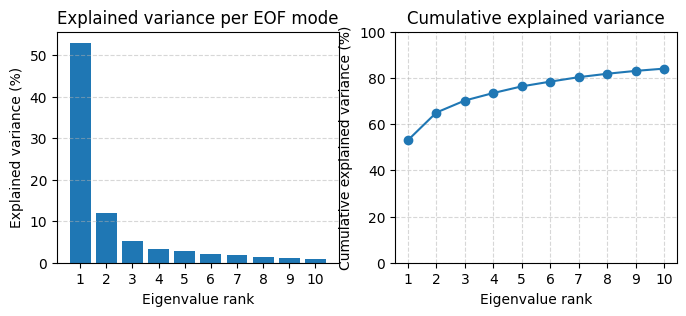

In [22]:
# explained variance by each mode
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3))
axes = axes.flatten()
axes[0].bar(range(1, n_modes + 1),  explained_variance)

axes[0].set_ylabel('Explained variance (%)')
axes[0].set_xlabel('Eigenvalue rank')
axes[0].set_title('Explained variance per EOF mode')
axes[0].set_xticks(range(1, n_modes + 1))
axes[0].grid(axis='y', ls='--', alpha=0.5)


axes[1].plot(range(1, n_modes + 1),  np.cumsum(explained_variance),  marker='o')
axes[1].set_ylabel('Cumulative explained variance (%)')
axes[1].set_xlabel('Eigenvalue rank')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xticks(range(1, n_modes + 1))
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.show()

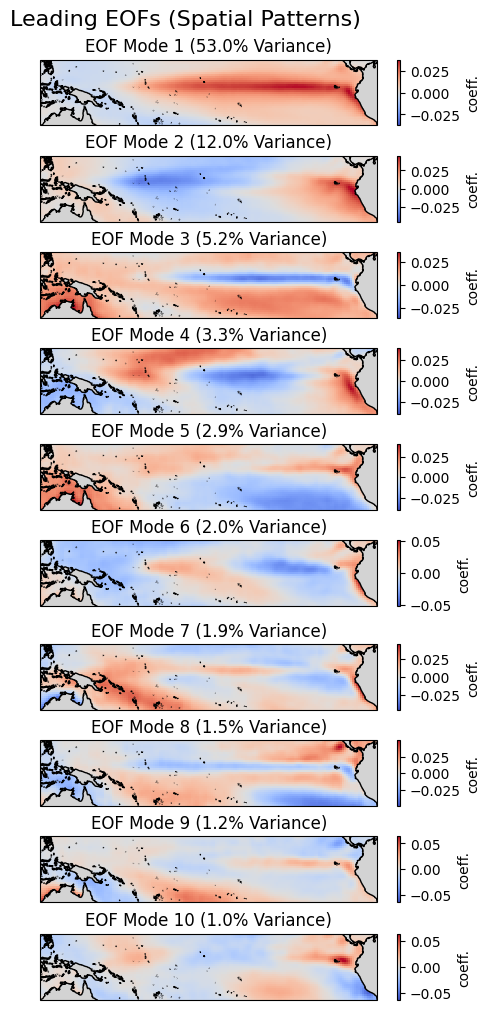

In [23]:
proj_enso = ccrs.PlateCarree(central_longitude=180)

eof_maps = []
for i in range(n_modes):
    da_flat = xr.DataArray(eofs_unit[i], coords={"z": sst_flat.z}, dims="z")
    da_map_weighted = da_flat.unstack("z")
    da_map_physical = da_map_weighted / weights_tropical
    eof_maps.append(da_map_physical)

fig, axes = plt.subplots(nrows=n_modes, ncols=1, figsize=(6, n_modes), subplot_kw={'projection': proj_enso}, constrained_layout=True)

# Plotting Loop
for i, ax in enumerate(axes):
    im = eof_maps[i].plot(ax=ax, transform=proj, cmap='coolwarm', center=0, add_colorbar = True,
        cbar_kwargs={'label': 'coeff.', 'fraction': 0.01, 'pad': 0.04})
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, facecolor='lightgray')
    var_exp = explained_variance[i]
    ax.set_title(f'EOF Mode {i+1} ({var_exp:.1f}% Variance)')

plt.suptitle("Leading EOFs (Spatial Patterns)", fontsize=16)
plt.show()

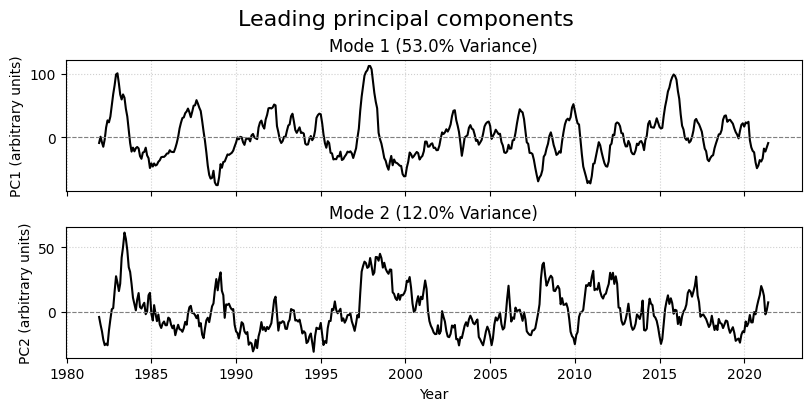

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 4), sharex=True, constrained_layout = True)

for i in range(2):
    ax = axes[i]
    ax.plot(sst_tropical.time, pcs[:, i], color='black', label=f'PC {i+1}')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    var_exp = explained_variance[i]
    ax.set_title(f'Mode {i+1} ({var_exp:.1f}% Variance)')
    ax.set_ylabel(f'PC{i+1} (arbitrary units)')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Year')
plt.suptitle("Leading principal components", fontsize=16)
plt.show()

In [30]:
# PCs (3-month smooth to match ONI definition)
df_pcs = pd.DataFrame(pcs[:, :2], index=sst_tropical.time.to_pandas(), columns=["PC1", "PC2"])
df_pcs_smooth = df_pcs.rolling(window=3, center=True).mean().dropna()

n34 = oni_34.to_series()

data = pd.concat([df_pcs_smooth, n34.rename("El Niño 3.4")], axis=1).dropna()

# Correlation: PC1/PC2 vs Niño 3.4
r = data[["PC1", "PC2"]].corrwith(data["El Niño 3.4"])
r_matrix = r.to_frame(name="El Niño 3.4")  # shape (2,1)



print("Pearson r PC1 vs Niño 3.4 =", r_matrix.loc["PC1", "El Niño 3.4"])
print("Pearson r PC1 vs Niño 3.4 =", r_matrix.loc["PC2", "El Niño 3.4"])

Pearson r PC1 vs Niño 3.4 = 0.9584880361253226
Pearson r PC1 vs Niño 3.4 = -0.23645343510432584


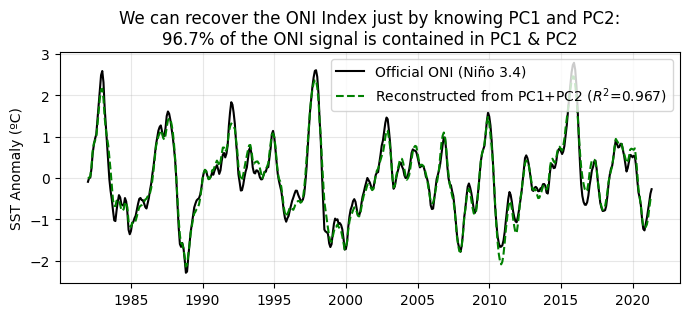

In [32]:
from sklearn.linear_model import LinearRegression

X = data[['PC1', 'PC2']]
y = data['El Niño 3.4']

reg = LinearRegression()
reg.fit(X, y)
y_reconstructed = reg.predict(X)
r2 = reg.score(X, y)

plt.figure(figsize=(8, 3))

plt.plot(y.index, y, color='black', label='Official ONI (Niño 3.4)')
plt.plot(y.index, y_reconstructed, color='green', linestyle='--', label=f'Reconstructed from PC1+PC2 ($R^2$={r2:.3f})')

plt.title(f"We can recover the ONI Index just by knowing PC1 and PC2:\n{r2:.1%} of the ONI signal is contained in PC1 & PC2")
plt.ylabel("SST Anomaly (ºC)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()